In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv("operation_tracking.csv")
df2 = df1[df1["variable"] == 'CDH'][["Q", "variable", "period", "ssp"]].groupby(["variable", "period", "ssp"]).max() * 1000
df3 = df2.reset_index()
print(df3)

tech_colors = {
    'Geothermal': (252/255,103/255,7/255),
    'HeatPump': (4/255,52/255,156/255), 
    'Boiler': (156/255,156/255,156/255),
    'unmet_demand': 'red',
    'BTES': '#9467bd'
    # Add more technologies as needed
}
ssp_colors = {
    'ssp126': ( 30/255,119/255,180/255),
    'ssp245': ( 81/255,158/255, 63/255),
    'ssp370': (238/255,134/255, 54/255),
    'ssp585': (196/255, 57/255, 50/255)
}

   variable period     ssp        Q
0       CDH  2020s    past   795.96
1       CDH  2030s  ssp126   663.30
2       CDH  2030s  ssp245   663.30
3       CDH  2030s  ssp370   751.74
4       CDH  2030s  ssp585   840.18
5       CDH  2040s  ssp126   751.74
6       CDH  2040s  ssp245   840.18
7       CDH  2040s  ssp370   707.52
8       CDH  2040s  ssp585   751.74
9       CDH  2050s  ssp126   663.30
10      CDH  2050s  ssp245   884.40
11      CDH  2050s  ssp370   751.74
12      CDH  2050s  ssp585   840.18
13      CDH  2060s  ssp126   707.52
14      CDH  2060s  ssp245   840.18
15      CDH  2060s  ssp370   795.96
16      CDH  2060s  ssp585   840.18
17      CDH  2070s  ssp126   707.52
18      CDH  2070s  ssp245   795.96
19      CDH  2070s  ssp370   884.40
20      CDH  2070s  ssp585  1105.50
21      CDH  2080s  ssp126   795.96
22      CDH  2080s  ssp245   840.18
23      CDH  2080s  ssp370   840.18
24      CDH  2080s  ssp585   928.62
25      CDH  2090s  ssp126   707.52
26      CDH  2090s  ssp245  

/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_35149/1868965249.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_35149/1868965249.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_35149/1868965249.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_35149/1868965249.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

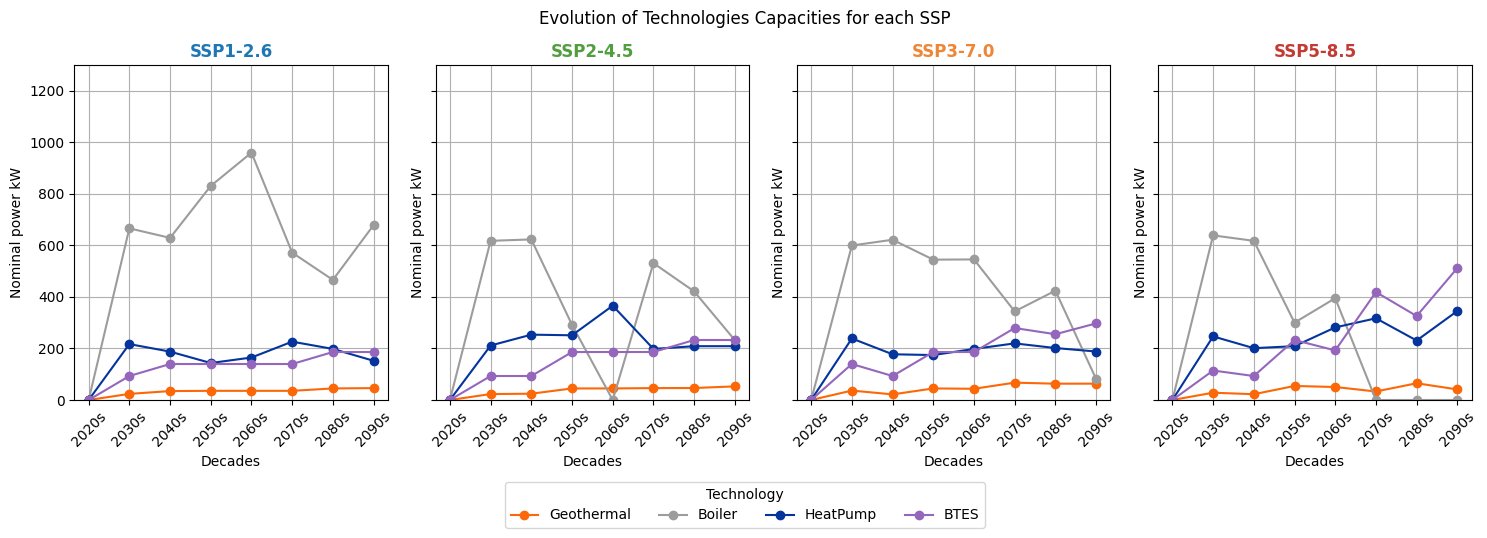

In [6]:
df = pd.read_csv("tech_tracking.csv")
# print(df)


tech_colors = {
    'Geothermal': (252/255,103/255,7/255),
    'HeatPump': (4/255,52/255,156/255), 
    'Boiler': (156/255,156/255,156/255),
    'unmet_demand': 'red',
    'BTES': '#9467bd'
    # Add more technologies as needed
}

colors = {
    'ssp126': ( 30/255,119/255,180/255),
    'ssp245': ( 81/255,158/255, 63/255),
    'ssp370': (238/255,134/255, 54/255),
    'ssp585': (196/255, 57/255, 50/255)
}

ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]
fig, axs = plt.subplots(1, len(ssps), figsize=(15, 5), sharey = True)

# Store legend handles and labels
legend_handles = None
legend_labels = None
    
for i, ssp in enumerate([s for s in df["ssp"].unique() if s != "past"]):
    ax = axs[i]
    
    ax.set_title(f'SSP{ssp[3]}-{ssp[4]}.{ssp[5]}', color = ssp_colors[ssp], fontweight='bold')
    for tech in [s for s in df["tech"].unique() if s != "past"]:
        subdf = df.loc[(df["tech"] == tech) & (df["ssp"] == ssp) | (df["ssp"] == "past")]
        # print(subdf)
        ax.plot(subdf["period"], subdf["power"] * 1e3, color = tech_colors[tech], marker = 'o', label=tech)
    # ax.grid()
    ax.set_ylabel("Nominal power kW")
    ax.set_xlabel("Decades")
    ax.set_ylim((0,1300))
    ax.grid()
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    # Store legend info from first subplot
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

# props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor = (200/255,200/255,250/255), linewidth = 2)
# plt.annotate("Cooling",xy = (5.5,50), ha = 'center', bbox=props)
# props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor = (230/255,0/255,0/255), linewidth = 2)
# plt.annotate("Heating",xy = (5.5,45), ha = 'center', bbox=props)
# # Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, 
           title='Technology', 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.05),
           ncol=len(legend_labels))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top = 0.87)  # Make space for the legend
fig.suptitle("Evolution of Technologies Capacities for each SSP")
plt.savefig("Technology_evolution.pdf", bbox_inches='tight', dpi=300)
plt.show()

      quantile variable        count    technology  heat_production  \
0            1      CDH   617.750000      HeatPump          0.04422   
1            2      CDH   517.875000      HeatPump          0.08844   
2            3      CDH   421.958333      HeatPump          0.13266   
3            4      CDH   333.791667      HeatPump          0.17688   
4            5      CDH   249.000000      HeatPump          0.22110   
...        ...      ...          ...           ...              ...   
6242         5      HDH  3057.666667  unmet_demand          0.00000   
6243         4      HDH  3396.333333  unmet_demand          0.00000   
6244         3      HDH  3791.000000  unmet_demand          0.00000   
6245         2      HDH  4124.333333  unmet_demand          0.00000   
6246         1      HDH  4352.833333  unmet_demand          0.00000   

      primary_energy  CO2_emissions      OpEx        Q period     ssp  
0           0.003168       0.000475  0.959523  0.04422  2020s    past  
1  

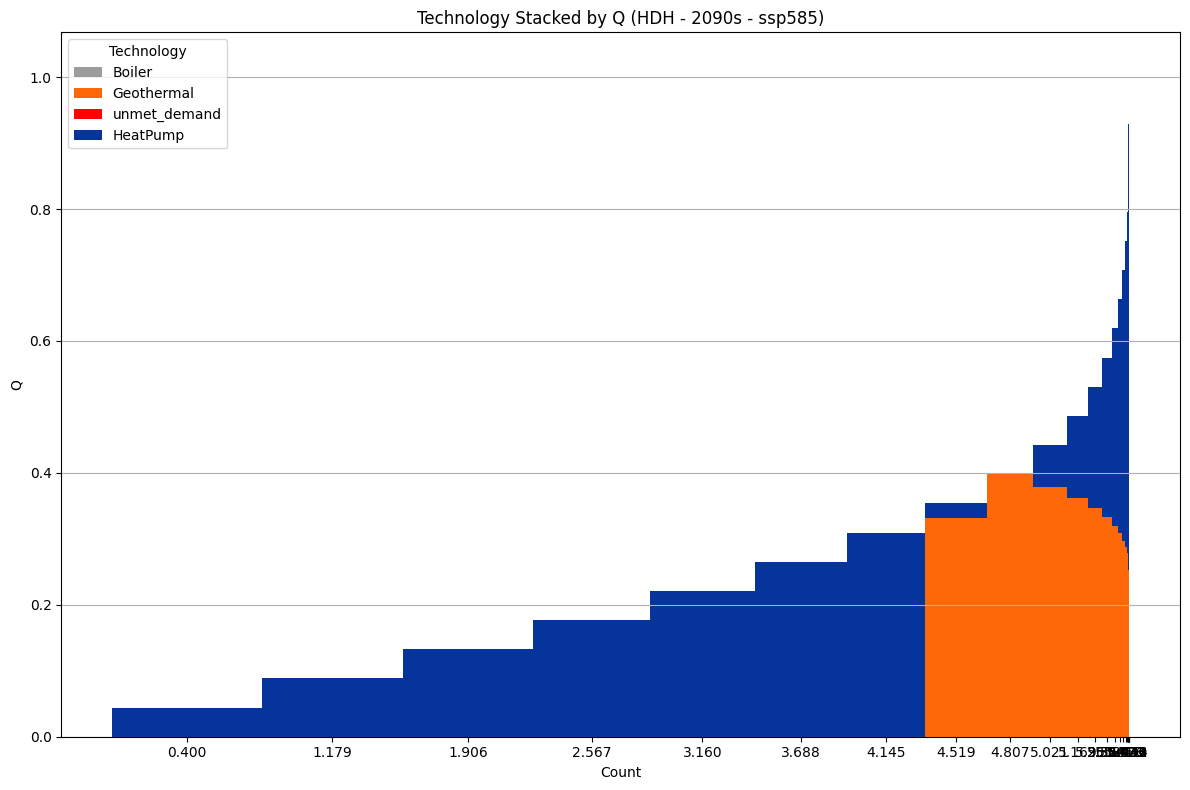

In [444]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tech_colors = {
    'Geothermal': (252/255,103/255,7/255),
    'HeatPump': (4/255,52/255,156/255), 
    'Boiler': (156/255,156/255,156/255),
    'unmet_demand': 'red',
    'BTES': '#9467bd'
    # Add more technologies as needed
}
df = pd.read_csv("operation_tracking.csv")
print(df)
ssp = "ssp585"
period = "2090s"
variable = "HDH"

filtered_df = df[
    (df["ssp"] == ssp) &
    (df["period"] == period) &
    (df["variable"] == variable)
]

filtered_df = filtered_df.iloc[::-1]
# Group by count and technology, sum Q values
pivot = filtered_df.pivot(index=["quantile","count"], columns=["technology"], values="heat_production")
print(pivot)

# Preserve original order of 'count' as it appears in the filtered data
# count_values = pivot.index.get_level_values(1)
unique_counts = pivot.index.get_level_values(1).drop_duplicates()


# Get technologies and counts
technologies = pivot.columns
counts = pivot.index.get_level_values(1).astype(float)

# Widths proportional to count
widths = counts / counts.max() * 0.8  # scaled for nice display
# Compute x positions (side-by-side layout, preserving original order)
x_positions = np.cumsum(widths) - widths / 2

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12, 8))
bottom = np.zeros(len(widths))

for tech in ["Boiler","Geothermal","unmet_demand","HeatPump"]:
    ax.bar(
        x_positions,
        pivot[tech],
        bottom=bottom,
        width=widths,
        label=tech,
        align='center',
        color = tech_colors[tech]
    )
    
    # Set xticks separately
    ax.set_xticks(x_positions)
    bottom += pivot[tech].values

# Axis labels, legend, title
ax.set_xticks(x_positions)
# ax.set_xticklabels(grouped.index)
ax.set_xlabel("Count")
ax.set_ylabel("Q")
ax.set_title(f"Technology Stacked by Q ({variable} - {period} - {ssp})")
ax.legend(title='Technology')
plt.grid(axis = "y")
plt.tight_layout()
plt.show()


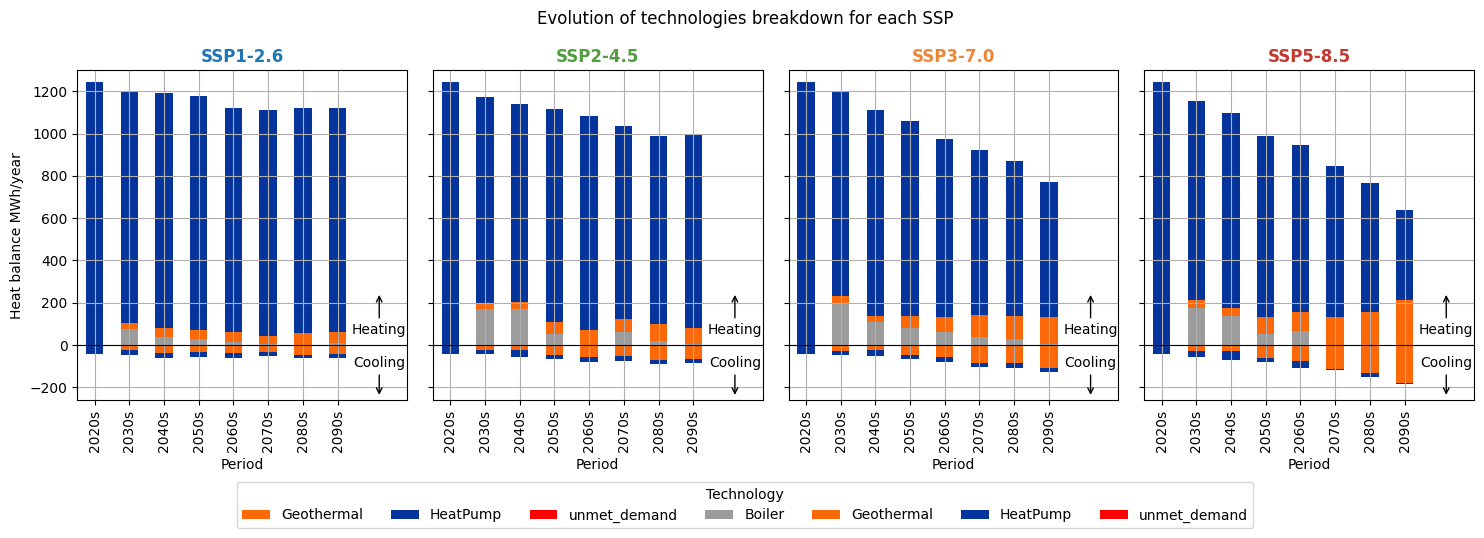

In [445]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("operation_tracking.csv")
df = df.iloc[::-1]
# Define custom colors for technologies
ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]
fig, axs = plt.subplots(1, len(ssps), figsize=(15, 5), sharey = True)

# Store legend handles and labels
legend_handles = None
legend_labels = None
    
for i, ssp in enumerate(ssps):
    ax = axs[i]
    filtered_df = df[
        ((df["ssp"] == ssp) | (df["ssp"] == "past")) &
        (df["variable"] == "CDH") &
        (df["technology"] != "BTES")
    ].copy()
    filtered_df.loc[:, 'count_heat_product'] = -filtered_df.loc[:, 'count'] * filtered_df.loc[:, 'heat_production'] / 10
    grouped = filtered_df.groupby(['period', 'technology'])['count_heat_product'].sum().unstack(fill_value=0)
    technologies = grouped.columns
    colors = [tech_colors.get(tech, '#000000') for tech in technologies]
    grouped.plot(kind='bar', stacked=True, ax=ax, color=colors, legend=False)

    
    ax = axs[i]
    filtered_df = df[
        ((df["ssp"] == ssp) | (df["ssp"] == "past")) &
        (df["variable"] == "HDH") &
        (df["technology"] != "BTES")
    ].copy()
    filtered_df.loc[:, 'count_heat_product'] = filtered_df.loc[:, 'count'] * filtered_df.loc[:, 'heat_production'] / 10
    grouped = filtered_df.groupby(['period', 'technology'])['count_heat_product'].sum().unstack(fill_value=0)
    technologies = grouped.columns
    colors = [tech_colors.get(tech, '#000000') for tech in technologies]
    grouped.plot(kind='bar', stacked=True, ax=ax, color=colors, legend=False)


    
    ax.set_ylabel('Heat balance MWh/year')
    ax.set_xlabel('Period')
    ax.set_title(f'SSP{ssp[3]}-{ssp[4]}.{ssp[5]}', color = ssp_colors[ssp], fontweight='bold')
    ax.grid()
    # Store legend info from first subplot
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    ax.annotate("Heating", xytext=(8.2, 50), xy=(8.2, 250), ha = 'center',
            arrowprops=dict(arrowstyle="->"))
    
    ax.annotate("Cooling", xytext=(8.2, -50), xy=(8.2, -250), ha = 'center', va = 'top',
            arrowprops=dict(arrowstyle="->"))
    
    ax.set_xlim(-0.5,9)
    ax.set_ylim(-260,1300)
# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, 
           title='Technology', 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.05),
           ncol=len(legend_labels))
fig.suptitle("Evolution of technologies breakdown for each SSP")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Make space for the legend
plt.savefig("energy_decomposition.pdf", bbox_inches='tight', dpi=300)
plt.show()

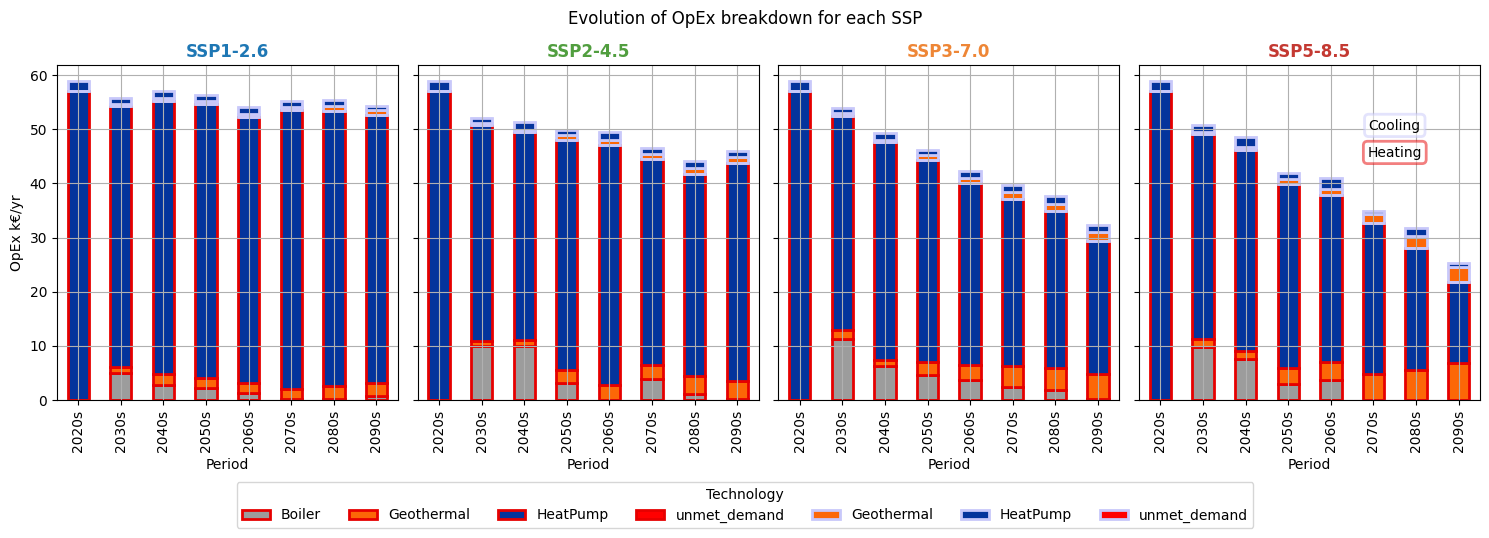

In [446]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("operation_tracking.csv")
df = df.iloc[::-1]
# Define custom colors for technologies
tech_colors = {
    'Geothermal': (252/255,103/255,7/255),
    'HeatPump': (4/255,52/255,156/255), 
    'Boiler': (156/255,156/255,156/255),
    'unmet_demand': 'red',
    'BTES': '#9467bd'
    # Add more technologies as needed
}

# for variable in ["HDH","CDH"]:

ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]
fig, axs = plt.subplots(1, len(ssps), figsize=(15, 5), sharey = True)

# Store legend handles and labels
legend_handles = None
legend_labels = None

for i, ssp in enumerate(ssps):
    ax = axs[i]
    
    # First plot: HDH (base)
    filtered_df_hdh = df[
        ((df["ssp"] == ssp) | (df["ssp"] == "past")) &
        (df["variable"] == "HDH") &
        (df["technology"] != "BTES") 
    ].copy()
    filtered_df_hdh['total_OpEx'] = filtered_df_hdh['count'] * filtered_df_hdh['OpEx'] / 10e3
    grouped_hdh = filtered_df_hdh.groupby(['period', 'technology'])['total_OpEx'].sum().unstack(fill_value=0)
    colors_hdh = [tech_colors.get(tech, '#000000') for tech in technologies_hdh]
    
    # Plot HDH as base
    grouped_hdh.plot(kind='bar', stacked=True, ax=ax, color=colors_hdh, legend=False, 
                     edgecolor=(230/255,0/255,0/255), linewidth=2)
    
    # Second plot: CDH (on top of HDH)
    filtered_df_cdh = df[
        ((df["ssp"] == ssp) | (df["ssp"] == "past")) &
        (df["variable"] == "CDH") &
        (df["technology"] != "BTES") 
    ].copy()
    filtered_df_cdh['total_OpEx'] = filtered_df_cdh['count'] * filtered_df_cdh['OpEx'] / 10e3
    grouped_cdh = filtered_df_cdh.groupby(['period', 'technology'])['total_OpEx'].sum().unstack(fill_value=0)
    technologies_cdh = grouped_cdh.columns
    colors_cdh = [tech_colors.get(tech, '#000000') for tech in technologies_cdh]
    
    # Calculate cumulative heights of HDH for each period to use as bottom for CDH
    hdh_cumulative = grouped_hdh.sum(axis=1)
    
    # Plot CDH on top of HDH
    bottom_positions = hdh_cumulative.values
    grouped_cdh.plot(kind='bar', stacked=True, ax=ax, color=colors_cdh, legend=False, 
                     edgecolor=(200/255,200/255,250/255), linewidth=2, bottom=bottom_positions)
    
    ax.set_ylabel('OpEx k€/yr')
    ax.set_xlabel('Period')
    ax.set_title(f'SSP{ssp[3]}-{ssp[4]}.{ssp[5]}', color = ssp_colors[ssp], fontweight='bold')
    ax.grid()
    
    # Store legend info from first subplot
    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor = (200/255,200/255,250/255), linewidth = 2)
plt.annotate("Cooling",xy = (5.5,50), ha = 'center', bbox=props)
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor = (230/255,0/255,0/255), linewidth = 2)
plt.annotate("Heating",xy = (5.5,45), ha = 'center', bbox=props)
# Add single legend for the entire figure
fig.legend(legend_handles, legend_labels, 
           title='Technology', 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.05),
           ncol=len(legend_labels))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top = 0.87)  # Make space for the legend
fig.suptitle("Evolution of OpEx breakdown for each SSP")
plt.savefig("OpEx_decomposed.pdf", bbox_inches='tight', dpi=300)
plt.show()